In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

os.makedirs("Images", exist_ok=True)

print(" Libraries imported and Images folder ready.")


 Libraries imported and Images folder ready.


In [2]:
df = pd.read_csv("diabetes.csv")

print(" Data loaded.")
print("\n--- First 5 rows ---")
display(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Summary statistics (numeric columns) ---")
display(df.describe())


 Data loaded.

--- First 5 rows ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- Summary statistics (numeric columns) ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
cols_with_invalid_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("--- Zero counts before cleaning ---")
for col in cols_with_invalid_zero:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros")

df[cols_with_invalid_zero] = df[cols_with_invalid_zero].replace(0, np.nan)

print("\n--- Missing values after converting zeros to NaN ---")
print(df.isna().sum())


--- Zero counts before cleaning ---
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros

--- Missing values after converting zeros to NaN ---
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


--- Q2(a) Glucose – Sample vs Population ---
Sample size                           : 25
Sample mean Glucose                   : 134.80
Population mean Glucose               : 121.69
Sample maximum Glucose                : 187.00
Population maximum Glucose            : 199.00


/var/folders/47/t16jhsbn4bd8hn2t5mzdrwrr0000gn/T/ipykernel_23188/843884966.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette="coolwarm")


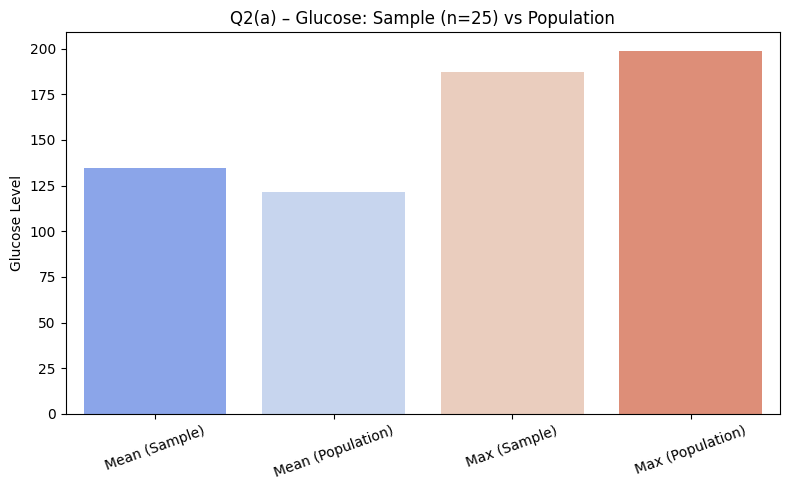

In [4]:
np.random.seed(42)

df_glucose = df.dropna(subset=['Glucose'])

sample_a = df_glucose.sample(n=25, random_state=42)

sample_mean_glu = sample_a['Glucose'].mean()
sample_max_glu  = sample_a['Glucose'].max()

pop_mean_glu = df_glucose['Glucose'].mean()
pop_max_glu  = df_glucose['Glucose'].max()

print("--- Q2(a) Glucose – Sample vs Population ---")
print(f"Sample size                           : {len(sample_a)}")
print(f"Sample mean Glucose                   : {sample_mean_glu:.2f}")
print(f"Population mean Glucose               : {pop_mean_glu:.2f}")
print(f"Sample maximum Glucose                : {sample_max_glu:.2f}")
print(f"Population maximum Glucose            : {pop_max_glu:.2f}")

metrics = ['Mean (Sample)', 'Mean (Population)', 'Max (Sample)', 'Max (Population)']
values  = [sample_mean_glu,      pop_mean_glu,   sample_max_glu,   pop_max_glu]

plt.figure(figsize=(8,5))
sns.barplot(x=metrics, y=values, palette="coolwarm")
plt.title("Q2(a) – Glucose: Sample (n=25) vs Population")
plt.ylabel("Glucose Level")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("Images/Q2a_glucose_sample_vs_population.png", bbox_inches="tight", dpi=300)
plt.show()


Sample size used for BMI (after dropping NaN): 24
--- Q2(b) BMI 98th Percentile ---
Sample 98th percentile of BMI      : 47.39
Population 98th percentile of BMI  : 47.77


/var/folders/47/t16jhsbn4bd8hn2t5mzdrwrr0000gn/T/ipykernel_23188/3670088315.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Sample 98%', 'Population 98%'],


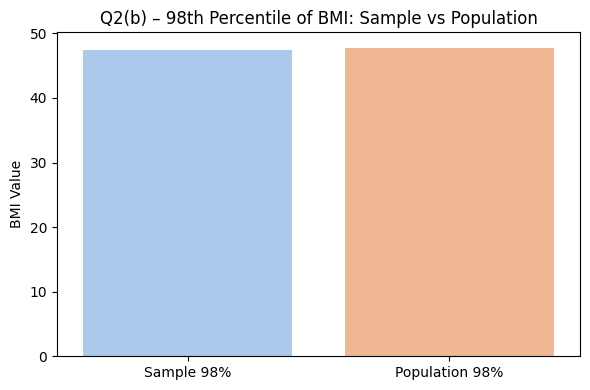

In [5]:
df_bmi = df.dropna(subset=['BMI'])

sample_b = df_bmi.loc[sample_a.index.intersection(df_bmi.index)]

print(f"Sample size used for BMI (after dropping NaN): {len(sample_b)}")

sample_bmi_98 = np.nanpercentile(sample_b['BMI'], 98)
pop_bmi_98    = np.nanpercentile(df_bmi['BMI'], 98)

print("--- Q2(b) BMI 98th Percentile ---")
print(f"Sample 98th percentile of BMI      : {sample_bmi_98:.2f}")
print(f"Population 98th percentile of BMI  : {pop_bmi_98:.2f}")

plt.figure(figsize=(6,4))
sns.barplot(x=['Sample 98%', 'Population 98%'],
            y=[sample_bmi_98, pop_bmi_98],
            palette="pastel")
plt.title("Q2(b) – 98th Percentile of BMI: Sample vs Population")
plt.ylabel("BMI Value")
plt.tight_layout()

plt.savefig("Images/Q2b_BMI_98th_percentile.png", bbox_inches="tight", dpi=300)
plt.show()


In [6]:
df_bp = df.dropna(subset=['BloodPressure']).copy()

print(f"Population size with valid BloodPressure: {len(df_bp)}")

np.random.seed(42)

n_boot = 500       
sample_size = 150  

boot_means = []
boot_stds  = []
boot_p98   = []

for _ in range(n_boot):
    sample_c = df_bp.sample(n=sample_size, replace=True)
    bp = sample_c['BloodPressure']
    
    boot_means.append(bp.mean())
    boot_stds.append(bp.std(ddof=1))
    boot_p98.append(np.percentile(bp, 98))

boot_df = pd.DataFrame({
    'Mean': boot_means,
    'SD':   boot_stds,
    'P98':  boot_p98
})

print("\n--- Bootstrap Summary (over 500 samples) ---")
display(boot_df.describe().T)

pop_mean_bp = df_bp['BloodPressure'].mean()
pop_sd_bp   = df_bp['BloodPressure'].std(ddof=1)
pop_p98_bp  = np.percentile(df_bp['BloodPressure'], 98)

print("\n--- Population BloodPressure statistics ---")
print(f"Population Mean      : {pop_mean_bp:.2f}")
print(f"Population SD        : {pop_sd_bp:.2f}")
print(f"Population 98th pct  : {pop_p98_bp:.2f}")


Population size with valid BloodPressure: 733

--- Bootstrap Summary (over 500 samples) ---


,count,mean,std,min,25%,50%,75%,max
Mean,500.0,72.334507,1.027334,69.160000,71.700000,72.380000,73.021667,75.146667
SD,500.0,12.295225,0.828609,9.995097,11.764944,12.322916,12.772578,14.929665
P98,500.0,98.203560,5.252317,88.000000,94.040000,98.000000,102.050000,110.080000



--- Population BloodPressure statistics ---
Population Mean      : 72.41
Population SD        : 12.38
Population 98th pct  : 100.00


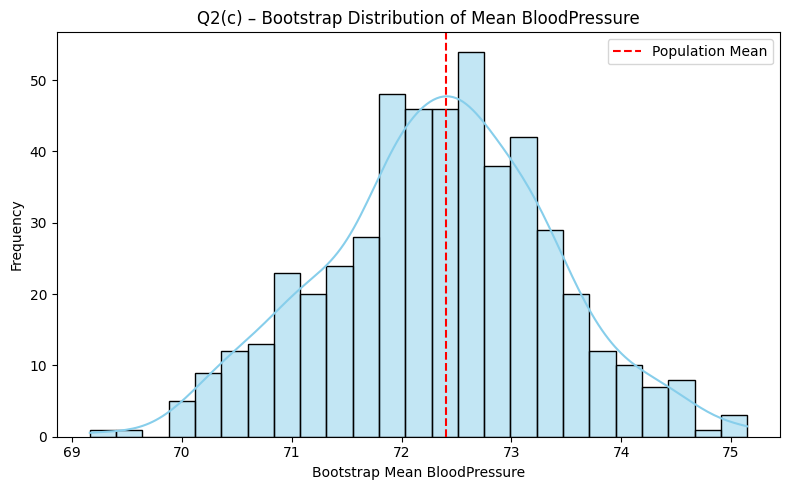

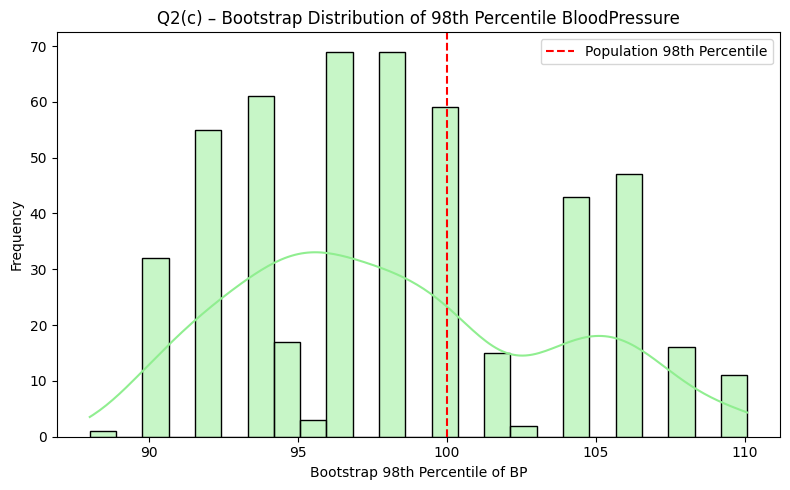

In [7]:
plt.figure()
sns.histplot(boot_df['Mean'], bins=25, kde=True, color='skyblue')
plt.axvline(pop_mean_bp, color='red', linestyle='--', label='Population Mean')
plt.title("Q2(c) – Bootstrap Distribution of Mean BloodPressure")
plt.xlabel("Bootstrap Mean BloodPressure")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("Images/Q2c_bootstrap_mean_BP.png", bbox_inches="tight", dpi=300)
plt.show()

plt.figure()
sns.histplot(boot_df['P98'], bins=25, kde=True, color='lightgreen')
plt.axvline(pop_p98_bp, color='red', linestyle='--', label='Population 98th Percentile')
plt.title("Q2(c) – Bootstrap Distribution of 98th Percentile BloodPressure")
plt.xlabel("Bootstrap 98th Percentile of BP")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("Images/Q2c_bootstrap_P98_BP.png", bbox_inches="tight", dpi=300)
plt.show()
